# Kernel Regression for k-Parity

This notebook runs kernel ridge regression on a parity task over inputs in `{ -1, +1 }^d`.

- Choose the input dimension `d`.
- Choose `parity_indices`, the coordinates whose product defines the label.
- Plug in any kernel function `kernel(X, Y)` that returns the pairwise kernel matrix between rows of `X` and rows of `Y`.
- Run the dot-product kernel experiment as the number of training samples grows up to `N_train_max`.
- Save and plot the loss as a function of the training set size.

In [1]:
from pathlib import Path

import gc
import itertools
import math
import matplotlib.pyplot as plt
import pandas as pd
import torch

plt.style.use("seaborn-v0_8-whitegrid")


## Configuration

Edit these values for a different parity problem or sample-size sweep.

In [15]:
# Input dimension.
d = 20

# Coordinates used for the k-parity label. Python uses zero-based indexing.
parity_indices = [0, 3, 7, 10, 12]

In [16]:
print(f"Total number of possible input sequences: {2**d}")

num_subsets = math.comb(d, len(parity_indices))
print(f"Number of subsets of size {len(parity_indices)}: {num_subsets}")


Total number of possible input sequences: 1048576
Number of subsets of size 5: 15504


In [20]:
# Maximum number of training samples to use.
N_train_max = 20000

# Number of held-out samples used to estimate the loss.
N_test = 10000

# Number of points in the training-size sweep.
num_train_sizes = 20

# Kernel ridge regularization. Increase this if the kernel matrix is ill-conditioned.
ridge = 1e-6

# Device options: "auto", "cuda", "mps", or "cpu".
# "auto" uses CUDA if available, then Apple MPS if available, otherwise CPU.
device_preference = "auto"

# Torch dtype. float32 is usually faster; float64 may be more stable.
torch_dtype = "float32"

# Evaluation batch size. Lower this if accelerator memory is tight.
eval_batch_size = 4096

# Normalization for the k-parity kernel. For +/-1 inputs, this makes K(x, x) = 1.
k_parity_kernel_normalization = 1.0 / math.comb(d, len(parity_indices))

# Normalization for K(x, y) = normalization * (x^T y)^k. For +/-1 inputs, this makes K(x, x) = 1.
dot_product_power_kernel_normalization = 1.0 / (d ** len(parity_indices))

# Reproducibility.
seed = 0

output_csv = Path("parity_kernel_losses.csv")


## Data and Kernel Regression Utilities

This notebook assumes PyTorch throughout. Set `device_preference = "cuda"` to require CUDA, or leave `device_preference = "auto"` to use CUDA when available and fall back to MPS/CPU otherwise. All kernels below use the same torch `kernel(X, Y)` interface.


In [21]:
def resolve_device(device_preference="auto"):
    """Choose a torch device from a requested preference."""
    if device_preference == "auto":
        if torch.cuda.is_available():
            return torch.device("cuda")
        if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")
    if device_preference == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError('device_preference="cuda" requested, but CUDA is not available')
        return torch.device("cuda")
    if device_preference == "mps":
        if getattr(torch.backends, "mps", None) is None or not torch.backends.mps.is_available():
            raise RuntimeError('device_preference="mps" requested, but Apple MPS is not available')
        return torch.device("mps")
    if device_preference == "cpu":
        return torch.device("cpu")
    raise ValueError("device_preference must be one of: 'auto', 'cuda', 'mps', 'cpu'")


def resolve_dtype(torch_dtype):
    if torch_dtype == "float32":
        return torch.float32
    if torch_dtype == "float64":
        return torch.float64
    raise ValueError("torch_dtype must be 'float32' or 'float64'")


def sample_pm1(n, d, device, dtype):
    """Sample n vectors uniformly from { -1, +1 }^d as a torch tensor."""
    bits = torch.randint(0, 2, (n, d), device=device)
    return bits.to(dtype=dtype).mul_(2).sub_(1)


def parity_labels(X, indices):
    """Compute k-parity labels prod_{i in indices} X_i for each row of X."""
    indices = list(indices)
    if not indices:
        return torch.ones(X.shape[0], device=X.device, dtype=X.dtype)
    if min(indices) < 0 or max(indices) >= X.shape[1]:
        raise ValueError("parity_indices must be valid zero-based column indices of X")
    index_tensor = torch.tensor(indices, device=X.device, dtype=torch.long)
    return torch.prod(X[:, index_tensor], dim=1)


def dot_product_kernel(X, Y):
    """Standard dot-product kernel K(x, y) = x^T y."""
    return X @ Y.T


def normalized_dot_product_kernel(X, Y):
    """Normalized dot-product kernel K(x, y) = x^T y / d."""
    return (X @ Y.T) / X.shape[1]


def dot_product_power_kernel(X, Y, power, normalization=1.0):
    """Power dot-product kernel K(x, y) = normalization * (x^T y)^power."""
    return normalization * ((X @ Y.T) ** power)


def make_dot_product_power_kernel(power, normalization=1.0):
    """Create a power dot-product kernel with fixed power."""
    def kernel(X, Y):
        return dot_product_power_kernel(X, Y, power=power, normalization=normalization)

    return kernel


def k_parity_combinations(d, k):
    """All coordinate subsets of size k."""
    if k < 0 or k > d:
        raise ValueError("k must satisfy 0 <= k <= d")
    return list(itertools.combinations(range(d), k))


def k_parity_feature_map(X, k):
    """Map each row x to all k-parity features prod_{i in S} x_i."""
    if k == 0:
        return torch.ones((X.shape[0], 1), device=X.device, dtype=X.dtype)
    combo_idx = torch.tensor(k_parity_combinations(X.shape[1], k), device=X.device, dtype=torch.long)
    return torch.prod(X[:, combo_idx], dim=2)


def k_parity_kernel(X, Y, k, normalization=1.0):
    """Dot product of k-parity feature maps, scaled by normalization."""
    Phi_X = k_parity_feature_map(X, k)
    Phi_Y = k_parity_feature_map(Y, k)
    return normalization * (Phi_X @ Phi_Y.T)


def make_k_parity_kernel(k, normalization=1.0):
    """Create a k-parity kernel with fixed k and normalization."""
    def kernel(X, Y):
        return k_parity_kernel(X, Y, k=k, normalization=normalization)

    return kernel


def k_l_feature_map(X, k, l):
    """Concatenate all k-parity and l-parity features for each row of X."""
    return torch.cat([k_parity_feature_map(X, k), k_parity_feature_map(X, l)], dim=1)


def k_l_kernel(X, Y, k, l, normalization=1.0):
    """Dot product of concatenated k- and l-parity feature maps."""
    Phi_X = k_l_feature_map(X, k, l)
    Phi_Y = k_l_feature_map(Y, k, l)
    return normalization * (Phi_X @ Phi_Y.T)


def make_k_l_kernel(k, l, normalization=1.0):
    """Create a kernel from combined k- and l-parity features."""
    def kernel(X, Y):
        return k_l_kernel(X, Y, k=k, l=l, normalization=normalization)

    return kernel


def kernel_ridge_predict(X_train, y_train, X_eval, kernel, ridge=1e-6, eval_batch_size=4096):
    """Fit kernel ridge regression and return predictions on X_eval as a CPU tensor."""
    K_train = alpha = K_batch = y_pred_batch = None
    prediction_batches = []
    try:
        with torch.inference_mode():
            K_train = kernel(X_train, X_train)
            K_train.diagonal().add_(ridge)
            alpha = torch.linalg.solve(K_train, y_train)

            for start in range(0, X_eval.shape[0], eval_batch_size):
                stop = min(start + eval_batch_size, X_eval.shape[0])
                K_batch = kernel(X_eval[start:stop], X_train)
                y_pred_batch = K_batch @ alpha
                prediction_batches.append(y_pred_batch.cpu())
                del K_batch, y_pred_batch
                K_batch = y_pred_batch = None

            return torch.cat(prediction_batches)
    finally:
        del K_train, alpha, K_batch, y_pred_batch
        clear_torch_memory(X_train.device)


def kernel_ridge_metrics(X_train, y_train, X_eval, y_eval, kernel, ridge=1e-6, eval_batch_size=4096):
    """Fit kernel ridge regression and return scalar MSE and classification error."""
    K_train = alpha = K_batch = y_pred_batch = None
    squared_error_sum = wrong_count = None
    try:
        with torch.inference_mode():
            K_train = kernel(X_train, X_train)
            K_train.diagonal().add_(ridge)
            alpha = torch.linalg.solve(K_train, y_train)

            squared_error_sum = torch.zeros((), device=X_eval.device, dtype=X_eval.dtype)
            wrong_count = torch.zeros((), device=X_eval.device, dtype=X_eval.dtype)
            for start in range(0, X_eval.shape[0], eval_batch_size):
                stop = min(start + eval_batch_size, X_eval.shape[0])
                K_batch = kernel(X_eval[start:stop], X_train)
                y_pred_batch = K_batch @ alpha
                y_true_batch = y_eval[start:stop]
                squared_error_sum += torch.sum((y_true_batch - y_pred_batch) ** 2)
                y_class_batch = torch.where(
                    y_pred_batch >= 0,
                    torch.ones_like(y_pred_batch),
                    -torch.ones_like(y_pred_batch),
                )
                wrong_count += torch.sum(y_class_batch != y_true_batch)
                del K_batch, y_pred_batch, y_true_batch, y_class_batch
                K_batch = y_pred_batch = None

            n_eval = X_eval.shape[0]
            return (squared_error_sum / n_eval).item(), (wrong_count / n_eval).item()
    finally:
        del K_train, alpha, K_batch, y_pred_batch
        del squared_error_sum, wrong_count
        clear_torch_memory(X_train.device)


def mse_loss(y_true, y_pred):
    return torch.mean((y_true.cpu() - y_pred.cpu()) ** 2).item()


def classification_error(y_true, y_pred):
    y_pred_cpu = y_pred.cpu()
    y_true_cpu = y_true.cpu()
    y_class = torch.where(y_pred_cpu >= 0, torch.ones_like(y_pred_cpu), -torch.ones_like(y_pred_cpu))
    return torch.mean((y_class.to(dtype=y_true_cpu.dtype) != y_true_cpu).to(torch.float32)).item()


def make_train_sizes(N_train_max, num_train_sizes):
    if num_train_sizes == 1:
        return [N_train_max]
    return torch.linspace(1, N_train_max, num_train_sizes).round().to(torch.long).unique().tolist()


def clear_torch_memory(device):
    """Release Python references and return cached accelerator memory to the backend."""
    gc.collect()
    if device.type == "cuda":
        torch.cuda.synchronize(device)
        torch.cuda.empty_cache()
    elif device.type == "mps":
        torch.mps.empty_cache()


## Single Regression Run Preview

This cell runs one kernel regression instance with fixed train/test sizes and plots predictions against true labels for a small subset of test samples.

Using device: cuda
Preview MSE: 0.380441
Preview classification error: 0.135


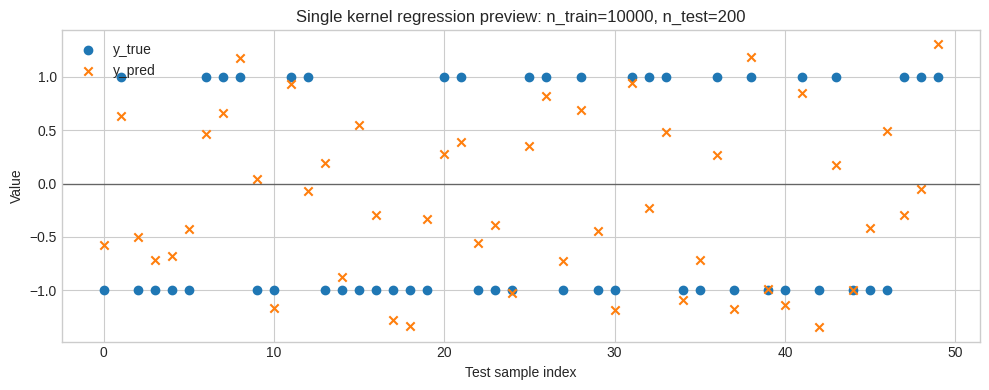

In [22]:
preview_N_train = min(10000, N_train_max)
preview_N_test = 200
num_plot_samples = 50

device = resolve_device(device_preference)
dtype = resolve_dtype(torch_dtype)
print(f"Using device: {device}")

torch.manual_seed(seed + 1)
X_preview_train = sample_pm1(preview_N_train, d, device, dtype)
y_preview_train = parity_labels(X_preview_train, parity_indices)
X_preview_test = sample_pm1(preview_N_test, d, device, dtype)
y_preview_true = parity_labels(X_preview_test, parity_indices)

preview_k = len(parity_indices)

# Kernel options. Uncomment exactly one block.
# kernel = make_k_parity_kernel(preview_k, normalization=k_parity_kernel_normalization)

# k_l_k = preview_k
# k_l_l = k_l_k + 1
# k_l_normalization = 1.0 / (math.comb(d, k_l_k) + math.comb(d, k_l_l))
# kernel = make_k_l_kernel(k_l_k, k_l_l, normalization=k_l_normalization)

kernel = make_dot_product_power_kernel(preview_k, normalization=dot_product_power_kernel_normalization)

y_preview_pred = kernel_ridge_predict(
    X_preview_train,
    y_preview_train,
    X_preview_test,
    kernel,
    ridge=ridge,
    eval_batch_size=eval_batch_size,
)

preview_mse = mse_loss(y_preview_true, y_preview_pred)
preview_error = classification_error(y_preview_true, y_preview_pred)
print(f"Preview MSE: {preview_mse:.6g}")
print(f"Preview classification error: {preview_error:.6g}")

plot_count = min(num_plot_samples, preview_N_test)
sample_idx = list(range(plot_count))
y_true_plot = y_preview_true[:plot_count].detach().cpu()
y_pred_plot = y_preview_pred[:plot_count].detach().cpu()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(sample_idx, y_true_plot, marker="o", label="y_true")
ax.scatter(sample_idx, y_pred_plot, marker="x", label="y_pred")
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.set_xlabel("Test sample index")
ax.set_ylabel("Value")
ax.set_title(f"Single kernel regression preview: n_train={preview_N_train}, n_test={preview_N_test}")
ax.legend()
fig.tight_layout()
plt.show()

del X_preview_train, y_preview_train, X_preview_test, y_preview_true, y_preview_pred
clear_torch_memory(device)


## Run Experiment

The experiment samples one maximum-size training set and one held-out test set. For each `n`, it trains on the first `n` training examples and evaluates on the same held-out test set, so the curve changes only because more training samples are added.

In [27]:
device = resolve_device(device_preference)
dtype = resolve_dtype(torch_dtype)
print(f"Using device: {device}")

torch.manual_seed(seed)
X_train_all = sample_pm1(N_train_max, d, device, dtype)
y_train_all = parity_labels(X_train_all, parity_indices)
X_test = sample_pm1(N_test, d, device, dtype)
y_test = parity_labels(X_test, parity_indices)

train_sizes = make_train_sizes(N_train_max, num_train_sizes)

preview_k = len(parity_indices)

# Kernel options. Uncomment exactly one block.
# kernel = dot_product_kernel
# kernel = make_k_parity_kernel(preview_k, normalization=k_parity_kernel_normalization)

# Example: combined k/l-parity feature kernel with feature map [phi_k(x), phi_l(x)].
k_l_k = len(parity_indices)
k_l_l = k_l_k - 1
k_l_normalization = 1.0 / (math.comb(d, k_l_k) + math.comb(d, k_l_l))
kernel = make_k_l_kernel(k_l_k, k_l_l, normalization=k_l_normalization)

# kernel = make_dot_product_power_kernel(preview_k, normalization=dot_product_power_kernel_normalization)

results = []
for n_train in train_sizes:
    print(n_train)
    X_train = X_train_all[:n_train]
    y_train = y_train_all[:n_train]

    mse, error = kernel_ridge_metrics(
        X_train,
        y_train,
        X_test,
        y_test,
        kernel,
        ridge=ridge,
        eval_batch_size=eval_batch_size,
    )
    results.append(
        {
            "n_train": n_train,
            "mse_loss": mse,
            "classification_error": error,
        }
    )
    del X_train, y_train
    clear_torch_memory(device)
    loss_df = pd.DataFrame(results)
    loss_df.to_csv(output_csv, index=False)

loss_df = pd.DataFrame(results)
loss_df.to_csv(output_csv, index=False)
loss_df.head(), output_csv


Using device: cuda
1
1054
2106
3159
4211
5264
6316
7369
8422
9474
10527
11579
12632
13685
14737
15790
16842
17895
18947
20000


(   n_train  mse_loss  classification_error
 0        1  0.999923                0.4983
 1     1054  0.955155                0.4148
 2     2106  0.901024                0.3687
 3     3159  0.852087                0.3432
 4     4211  0.797459                0.3110,
 PosixPath('parity_kernel_losses.csv'))

## Plot Loss vs. Number of Training Samples

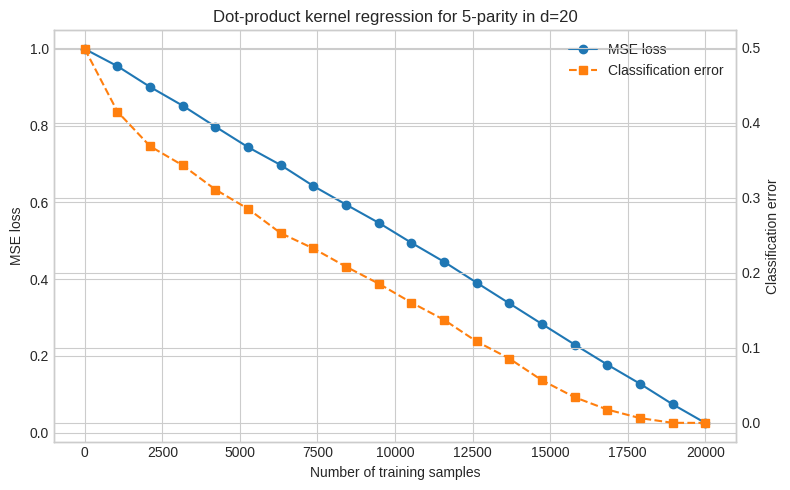

In [28]:
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(loss_df["n_train"], loss_df["mse_loss"], marker="o", label="MSE loss")
ax1.set_xlabel("Number of training samples")
ax1.set_ylabel("MSE loss")
ax1.set_title(f"Dot-product kernel regression for {len(parity_indices)}-parity in d={d}")

ax2 = ax1.twinx()
ax2.plot(
    loss_df["n_train"],
    loss_df["classification_error"],
    marker="s",
    linestyle="--",
    color="tab:orange",
    label="Classification error",
)
ax2.set_ylabel("Classification error")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

fig.tight_layout()
plt.show()

## Example: Custom Kernel

Define any pairwise torch kernel `kernel(X, Y)` that returns a pairwise kernel matrix. The regression helpers will run it on the selected torch device.


In [ ]:
def polynomial_kernel(X, Y, degree=2, bias=1.0, normalization=1.0):
    return normalization * ((bias + X @ Y.T) ** degree)


# To use it in the experiment above, set:
# kernel = lambda X, Y: polynomial_kernel(X, Y, degree=2, bias=1.0)
